# Correlation Analysis
## Music Streaming Pipeline — Notebook 2 of 3

This notebook extends the EDA by joining all six data sources into a single enriched dataset and running a full Pearson correlation analysis to identify which features are most linearly associated with song popularity.

### What We Did
- **Loaded and merged** six CSVs — songs, audio features, artists, albums, genres, and artist genres — into a single DataFrame of 18 numeric and categorical features
- **Cleaned the data** — dropped rows with null values (109k → ~52.7k rows), encoded `is_explicit` as 0/1, and filtered out rows with logically invalid values (zero BPM, zero energy, zero artist popularity, zero engagement ratio)
- **Confirmed data quality** — zero duplicate rows found
- **Built a Pearson correlation heatmap** sorted by absolute correlation with `popularity` to rank all features by their linear relationship strength
- **Ran scatter plots with regression lines and R² values** for the three strongest predictors of song popularity: `artist_popularity`, `song_listeners`, and `total_listeners`
- Rescaled listener counts to millions for readability and computed Pearson R² for each plot

### Key Findings
- `artist_popularity` was the strongest predictor of song popularity with **R² = 0.36** and a Pearson correlation of **0.60**
- `song_listeners` had a moderate relationship (**R² = 0.18**) but the data is heavily right-skewed, pulling the regression line beyond valid popularity bounds
- `total_listeners` had the weakest relationship (**R² = 0.10**), suggesting artist audience size alone does not reliably predict individual song success
- Both listener count variables would benefit from a log transformation to reduce the influence of extreme outliers

### Next Step
Notebook 03 moves into hypothesis testing — running two-sample t-tests to determine whether group differences (explicit vs clean songs, singles vs albums, etc.) are statistically significant or due to random chance.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

## LOAD TABLES

In [60]:
songs = pd.read_csv('../exports/songs.csv')
audio_features = pd.read_csv('../exports/song_audio_features.csv')
artists = pd.read_csv('../exports/artist.csv')
albums = pd.read_csv('../exports/albums.csv')
genres = pd.read_csv('../exports/genres.csv')
artist_genres = pd.read_csv('../exports/artist_genres.csv')

## MERGING TABLES

In [61]:
df = songs.merge(audio_features, on='song_id', how='inner')

In [62]:
df = df.merge(artists, on='artist_id', how='inner')

In [63]:
df = df.merge(albums, on='album_id', how='inner')

In [64]:
df.columns

Index(['song_id', 'song_name', 'artist_id_x', 'album_id', 'song_listeners',
       'mbid', 'duration_ms', 'duration_seconds', 'duration_minutes',
       'engagement_ratio', 'release_date', 'release_date_precision',
       'is_explicit', 'popularity', 'track_number', 'is_playable',
       'created_at_x', 'updated_at_x', 'bpm', 'energy', 'spectral_centroid',
       'zero_crossing_rate', 'danceability', 'preview_url', 'harmonic_ratio',
       'percussive_ratio', 'analysis_date', 'artist_name', 'on_tour',
       'total_listeners', 'total_playcount', 'plays_per_listener',
       'updated_at_y', 'created_at_y', 'artist_popularity', 'artist_followers',
       'has_genres', 'album_title', 'artist_id_y', 'album_type',
       'album_total_tracks', 'created_at', 'updated_at'],
      dtype='object')

In [65]:
df= df[['song_id', 'artist_id_x', 'album_id', 'song_listeners', 'duration_seconds', 
        'engagement_ratio', 'is_explicit', 'popularity', 'track_number', 
        'bpm', 'energy', 'spectral_centroid', 'zero_crossing_rate', 'total_listeners', 
        'total_playcount', 'plays_per_listener', 'artist_popularity', 'artist_followers']
        ].rename({'artist_id_x':'artist_id'}, axis=1)

Only selecting the columns that we want to use for this investigation.

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109291 entries, 0 to 109290
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   song_id             109291 non-null  object 
 1   artist_id           109291 non-null  object 
 2   album_id            109291 non-null  object 
 3   song_listeners      109291 non-null  int64  
 4   duration_seconds    109291 non-null  int64  
 5   engagement_ratio    87960 non-null   float64
 6   is_explicit         109291 non-null  object 
 7   popularity          109291 non-null  int64  
 8   track_number        109291 non-null  int64  
 9   bpm                 109291 non-null  float64
 10  energy              109291 non-null  float64
 11  spectral_centroid   109291 non-null  float64
 12  zero_crossing_rate  109291 non-null  float64
 13  total_listeners     109291 non-null  int64  
 14  total_playcount     109291 non-null  int64  
 15  plays_per_listener  97933 non-null

Quite a few null values for important artist features, we will have to filter for non null values.

In [67]:
df.sample(10)

,song_id,artist_id,album_id,song_listeners,duration_seconds,engagement_ratio,is_explicit,popularity,track_number,bpm,energy,spectral_centroid,zero_crossing_rate,total_listeners,total_playcount,plays_per_listener,artist_popularity,artist_followers
20645,7N3QHNvGHZvlc3yieARpyh,00iDXs6D2a9UZCtqnDMGnY,32CNxoLpFHBAedG6cAv5Nw,327,107,0.09211,f,14,10,112.347,0.16390,2981.829,0.13340,3557,28473,8.00478,NaN,NaN
38549,0KhrWadGHo3xqxlaa3pZko,78xUyw6FkVZrRAtziFdtdu,4hkERQVrmM9JQ9g2eie2tL,57698,218,0.02881,t,32,10,184.570,0.16647,2706.385,0.11145,2006153,59414437,29.61610,62.0,1519053.0
62451,33VEIkRrbklAUpWzkLx6hS,6HpbySgoX3F1Qi7NCa1fQe,3N2tnOD0qjl2EYIoXds23u,689,366,0.10603,f,4,9,95.703,0.09038,598.193,0.03707,6498,73129,11.25408,NaN,NaN
49608,7FeH5VouksptUKkOgU6QdZ,4fW6nh59aks65MaObUM7sb,4BMHrY378uEX3bfwfPpAn8,17,238,0.02716,f,11,1,135.999,0.28819,1875.026,0.05096,626,6986,11.15974,NaN,NaN
81581,0DoB2ZlTMjx9ptcO9CJLGJ,0QUBaF6Rtta4TTmxYYfzux,54vGSK50oe08qxz2xXECEC,22012,360,0.18218,f,67,70,117.454,0.04494,3088.970,0.17002,120828,40140632,332.21300,85.0,43514.0
79729,0EaZFQye8RZFrZtCAFuXIF,7gwu1NgWW8h1Uj0AbnLkMY,3lR64l1BAH254QsZs1BtC6,0,103,NaN,f,11,19,143.555,0.13180,1034.878,0.05105,7036,108848,15.47015,NaN,NaN
40051,66PfXpuPoNJ7fhvyAq7qlW,5LVfUFtAdRpEe3zTzZnQLp,4pqjIJQ1IAc1rSITQlpHAI,568,472,0.30037,f,26,1,151.999,0.35749,2631.323,0.12466,1891,17761,9.39238,NaN,NaN
58696,5LWXWLv2nlVAkEfOFWiIyt,6waa8mKu91GjzD4NlONlNJ,0fkWfmPjw7rH1fTB9uSvFJ,7343,172,0.00472,f,4,3,161.499,0.14224,2476.422,0.11509,1554157,15430314,9.92841,68.0,1379921.0
40673,0EJHhccadE8UvdZ5wGI1SN,3TNt4aUIxgfy9aoaft5Jj2,44ePwTuWK88vnalqutqJEG,544158,155,0.13777,f,48,2,143.555,0.28477,2774.582,0.14969,3953232,133410552,33.74721,68.0,1503279.0
85002,28EoUSbgczUEnqQoME0FBf,1pdutuLA4KPZHkeUEpmaPI,3YmYmeDGT3s0eSUKd3b7Ut,213,80,0.13584,t,14,1,95.703,0.16754,2502.177,0.08471,1568,8094,5.16199,NaN,NaN


In [68]:
df= df.dropna()

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52909 entries, 0 to 109290
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   song_id             52909 non-null  object 
 1   artist_id           52909 non-null  object 
 2   album_id            52909 non-null  object 
 3   song_listeners      52909 non-null  int64  
 4   duration_seconds    52909 non-null  int64  
 5   engagement_ratio    52909 non-null  float64
 6   is_explicit         52909 non-null  object 
 7   popularity          52909 non-null  int64  
 8   track_number        52909 non-null  int64  
 9   bpm                 52909 non-null  float64
 10  energy              52909 non-null  float64
 11  spectral_centroid   52909 non-null  float64
 12  zero_crossing_rate  52909 non-null  float64
 13  total_listeners     52909 non-null  int64  
 14  total_playcount     52909 non-null  int64  
 15  plays_per_listener  52909 non-null  float64
 16  artist_p

## FEATURE ENGINEERING

In [70]:

df['is_explicit'] = df['is_explicit'].map({'t': 1, 'f': 0})


Ensuring that the values we have are numerical so a correlation analysis can be performed on all of the features.

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52909 entries, 0 to 109290
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   song_id             52909 non-null  object 
 1   artist_id           52909 non-null  object 
 2   album_id            52909 non-null  object 
 3   song_listeners      52909 non-null  int64  
 4   duration_seconds    52909 non-null  int64  
 5   engagement_ratio    52909 non-null  float64
 6   is_explicit         52909 non-null  int64  
 7   popularity          52909 non-null  int64  
 8   track_number        52909 non-null  int64  
 9   bpm                 52909 non-null  float64
 10  energy              52909 non-null  float64
 11  spectral_centroid   52909 non-null  float64
 12  zero_crossing_rate  52909 non-null  float64
 13  total_listeners     52909 non-null  int64  
 14  total_playcount     52909 non-null  int64  
 15  plays_per_listener  52909 non-null  float64
 16  artist_p

Checking the data types to ensure they were transformed correctly.

## DATA FILTERING

In [72]:
df.describe()

,song_listeners,duration_seconds,engagement_ratio,is_explicit,popularity,track_number,bpm,energy,spectral_centroid,zero_crossing_rate,total_listeners,total_playcount,plays_per_listener,artist_popularity,artist_followers
count,5.290900e+04,52909.000000,52909.000000,52909.000000,52909.000000,52909.000000,52909.000000,52909.000000,52909.000000,52909.000000,5.290900e+04,5.290900e+04,52909.000000,52909.000000,5.290900e+04
mean,8.116599e+04,210.499253,0.377835,0.237559,35.823830,6.265872,120.227383,0.217943,2257.476074,0.097822,8.696749e+05,6.481476e+07,39.742783,57.054735,4.112315e+06
std,1.989225e+05,108.557234,15.886650,0.425591,19.123428,7.861188,28.787705,0.091054,687.288853,0.040474,1.330138e+06,2.471656e+08,77.868460,18.142433,1.453742e+07
min,1.000000e+01,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,12.888000,0.000000,2.000000e+00,3.000000e+00,1.000000,0.000000,1.000000e+00
25%,2.104000e+03,157.000000,0.013010,0.000000,21.000000,1.000000,99.384000,0.146630,1898.545000,0.069500,1.033870e+05,1.661146e+06,12.982260,45.000000,6.248100e+04
50%,1.135400e+04,200.000000,0.047810,0.000000,35.000000,4.000000,117.454000,0.214520,2367.601000,0.096220,2.999060e+05,6.130799e+06,21.762730,57.000000,3.280940e+05
75%,5.748000e+04,245.000000,0.137270,0.000000,50.000000,9.000000,143.555000,0.285070,2721.551000,0.124080,9.875560e+05,3.100561e+07,40.602550,70.000000,1.840471e+06
max,2.997538e+06,6000.000000,2248.659340,1.000000,98.000000,247.000000,287.109000,0.805060,5536.567000,0.571700,8.936677e+06,3.538159e+09,8135.496860,100.000000,1.710662e+08


In [73]:
df= df[df['engagement_ratio']>0]
df= df[df['bpm']>0]
df= df[df['energy']>0]
df= df[df['artist_popularity']>0]

Filtering the database to ensure that all the data is valid and operates under the logical constraints.
BPM, energy, artist popularity, and artist_popularity should all be above 0, therefore we filter our df to include only valid data.

In [74]:
df.describe()

,song_listeners,duration_seconds,engagement_ratio,is_explicit,popularity,track_number,bpm,energy,spectral_centroid,zero_crossing_rate,total_listeners,total_playcount,plays_per_listener,artist_popularity,artist_followers
count,5.270200e+04,52702.000000,52702.000000,52702.000000,52702.000000,52702.000000,52702.000000,52702.000000,52702.000000,52702.000000,5.270200e+04,5.270200e+04,52702.000000,52702.000000,5.270200e+04
mean,8.144392e+04,210.698380,0.378464,0.238359,35.806155,6.256385,120.618530,0.218205,2264.075853,0.098092,8.726690e+05,6.498322e+07,39.599605,57.073223,4.126553e+06
std,1.992604e+05,108.559599,15.917809,0.426084,19.107100,7.814115,28.012518,0.091047,678.756818,0.040273,1.331687e+06,2.473541e+08,77.694278,18.087833,1.455978e+07
min,1.000000e+01,15.000000,0.000010,0.000000,1.000000,1.000000,8.075000,0.000020,117.121000,0.000320,2.000000e+00,3.000000e+00,1.034480,1.000000,1.000000e+00
25%,2.117250e+03,157.000000,0.012960,0.000000,21.000000,1.000000,99.384000,0.146803,1905.194250,0.069800,1.045020e+05,1.670158e+06,13.011570,45.000000,6.325000e+04
50%,1.141450e+04,200.000000,0.047550,0.000000,35.000000,4.000000,117.454000,0.214950,2369.981500,0.096405,3.026750e+05,6.172180e+06,21.750355,57.000000,3.321770e+05
75%,5.781925e+04,246.000000,0.136667,0.000000,50.000000,9.000000,143.555000,0.285360,2722.811000,0.124190,9.943660e+05,3.119260e+07,40.541180,70.000000,1.860221e+06
max,2.997538e+06,6000.000000,2248.659340,1.000000,98.000000,247.000000,287.109000,0.805060,5536.567000,0.571700,8.936677e+06,3.538159e+09,8135.496860,100.000000,1.710662e+08


Ensuring that the filtering worked!

In [75]:
df.duplicated().sum()

np.int64(0)

There is no duplicated observations which means we don't have to filter the dataframe for duplicate values.


## CORRELATION ANALYSIS

In [76]:
df.columns

Index(['song_id', 'artist_id', 'album_id', 'song_listeners',
       'duration_seconds', 'engagement_ratio', 'is_explicit', 'popularity',
       'track_number', 'bpm', 'energy', 'spectral_centroid',
       'zero_crossing_rate', 'total_listeners', 'total_playcount',
       'plays_per_listener', 'artist_popularity', 'artist_followers'],
      dtype='object')

In [77]:
df_corr = df.drop(['song_id', 'artist_id', 'album_id'], axis=1)
df_corr.columns

Index(['song_listeners', 'duration_seconds', 'engagement_ratio', 'is_explicit',
       'popularity', 'track_number', 'bpm', 'energy', 'spectral_centroid',
       'zero_crossing_rate', 'total_listeners', 'total_playcount',
       'plays_per_listener', 'artist_popularity', 'artist_followers'],
      dtype='object')

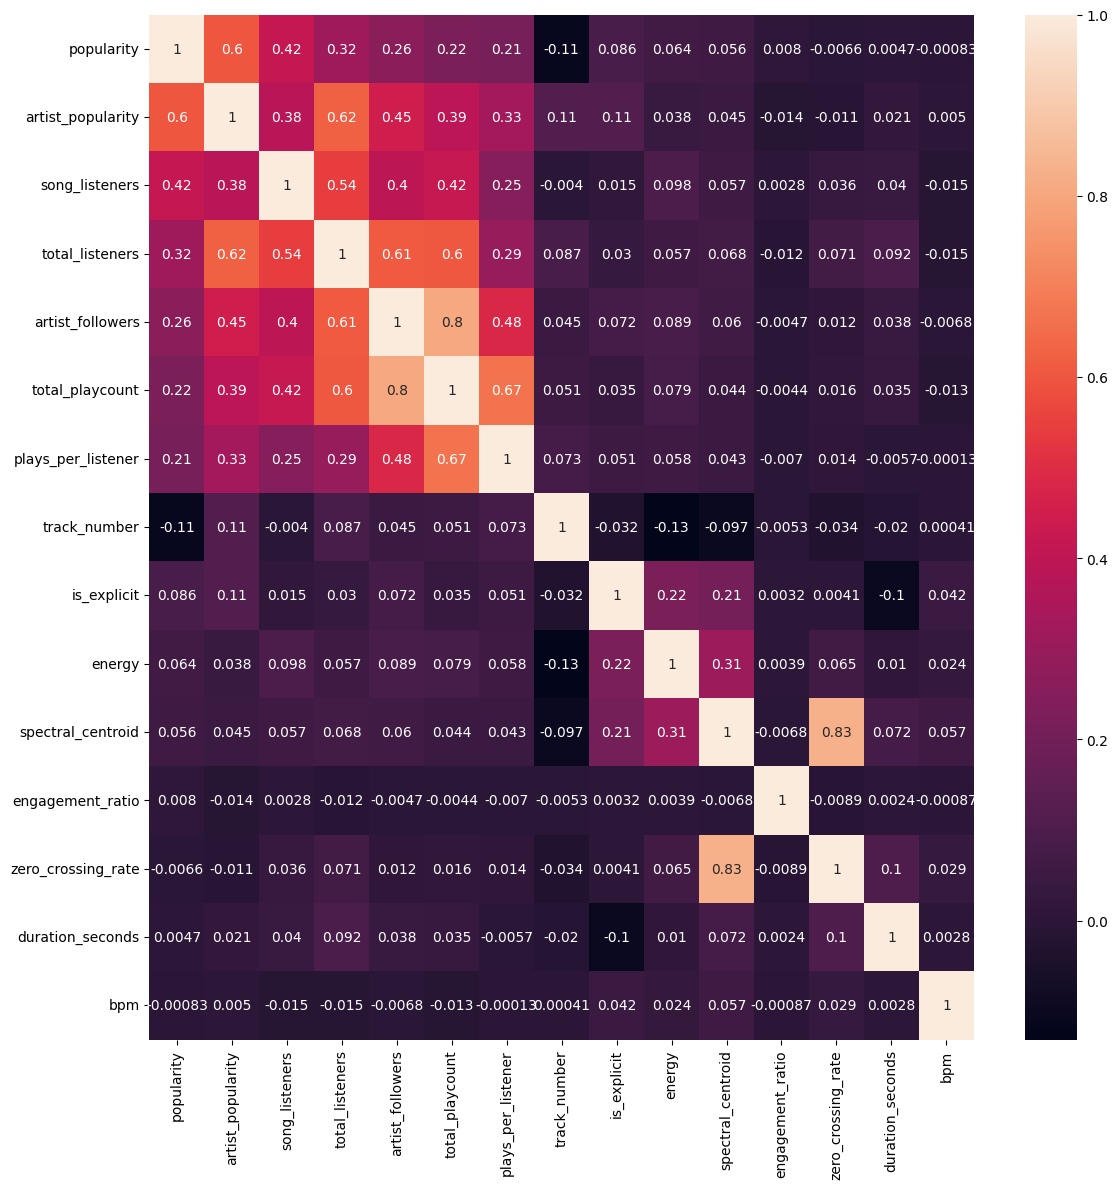

In [78]:
plt.figure(figsize=(12,12))
corr= df_corr.corr()
order = corr['popularity'].abs().sort_values(ascending=False).index
sorted_corr = corr.loc[order, order]
sns.heatmap(sorted_corr, annot=True)
plt.tight_layout()
plt.show()

The top three correlations observed for song popularity are artist_popularity, song_listeners, and total_listeners (artist metric). 

* Artist_popularity had the highest correlation of .6 which makes logical sense. While the innerworkings of the song popularity alogrithm isn't known to me, I would imagine that if an artist has a higher popularity metric their songs will have a better chance at charting/succeeding/streaming higher. For example Beyonce's least popular songs are more popular than most songs by "underground" artists due to her massive, loyal fanbase. A song with her name on it will recieve a number of streams because she is so established. This translated to playlist placements, streams, saves, etc which contribute to song popularity. 

* Song_listeners is moderately correlated with song_popularity (.42). This is likely due to song_listeners/streams playing a large role in how song popularity is calculated. However the correlation value isn't higher because there are likely other factors that play a role in song popularity like playlist placements, saves, or listener retention. 

* Total Listeners is also moderately correlated with song_popularity (.32). This metric is an artist-level metric that is the total number of artist listeners on Last.FM. While this isn't a Spotify statistic it can signal high artist interest which often is translated into streams. This follows the same logic as artist popularity because the more engaged listeners an artist has, more likely a specific song by that artist is heavily streamed. 



In [79]:
def get_regression_info(x, y):
    m, b = np.polyfit(x, y, 1)
    x_range = np.linspace(x.min(),x.max(), 200)
    return m, b, x_range


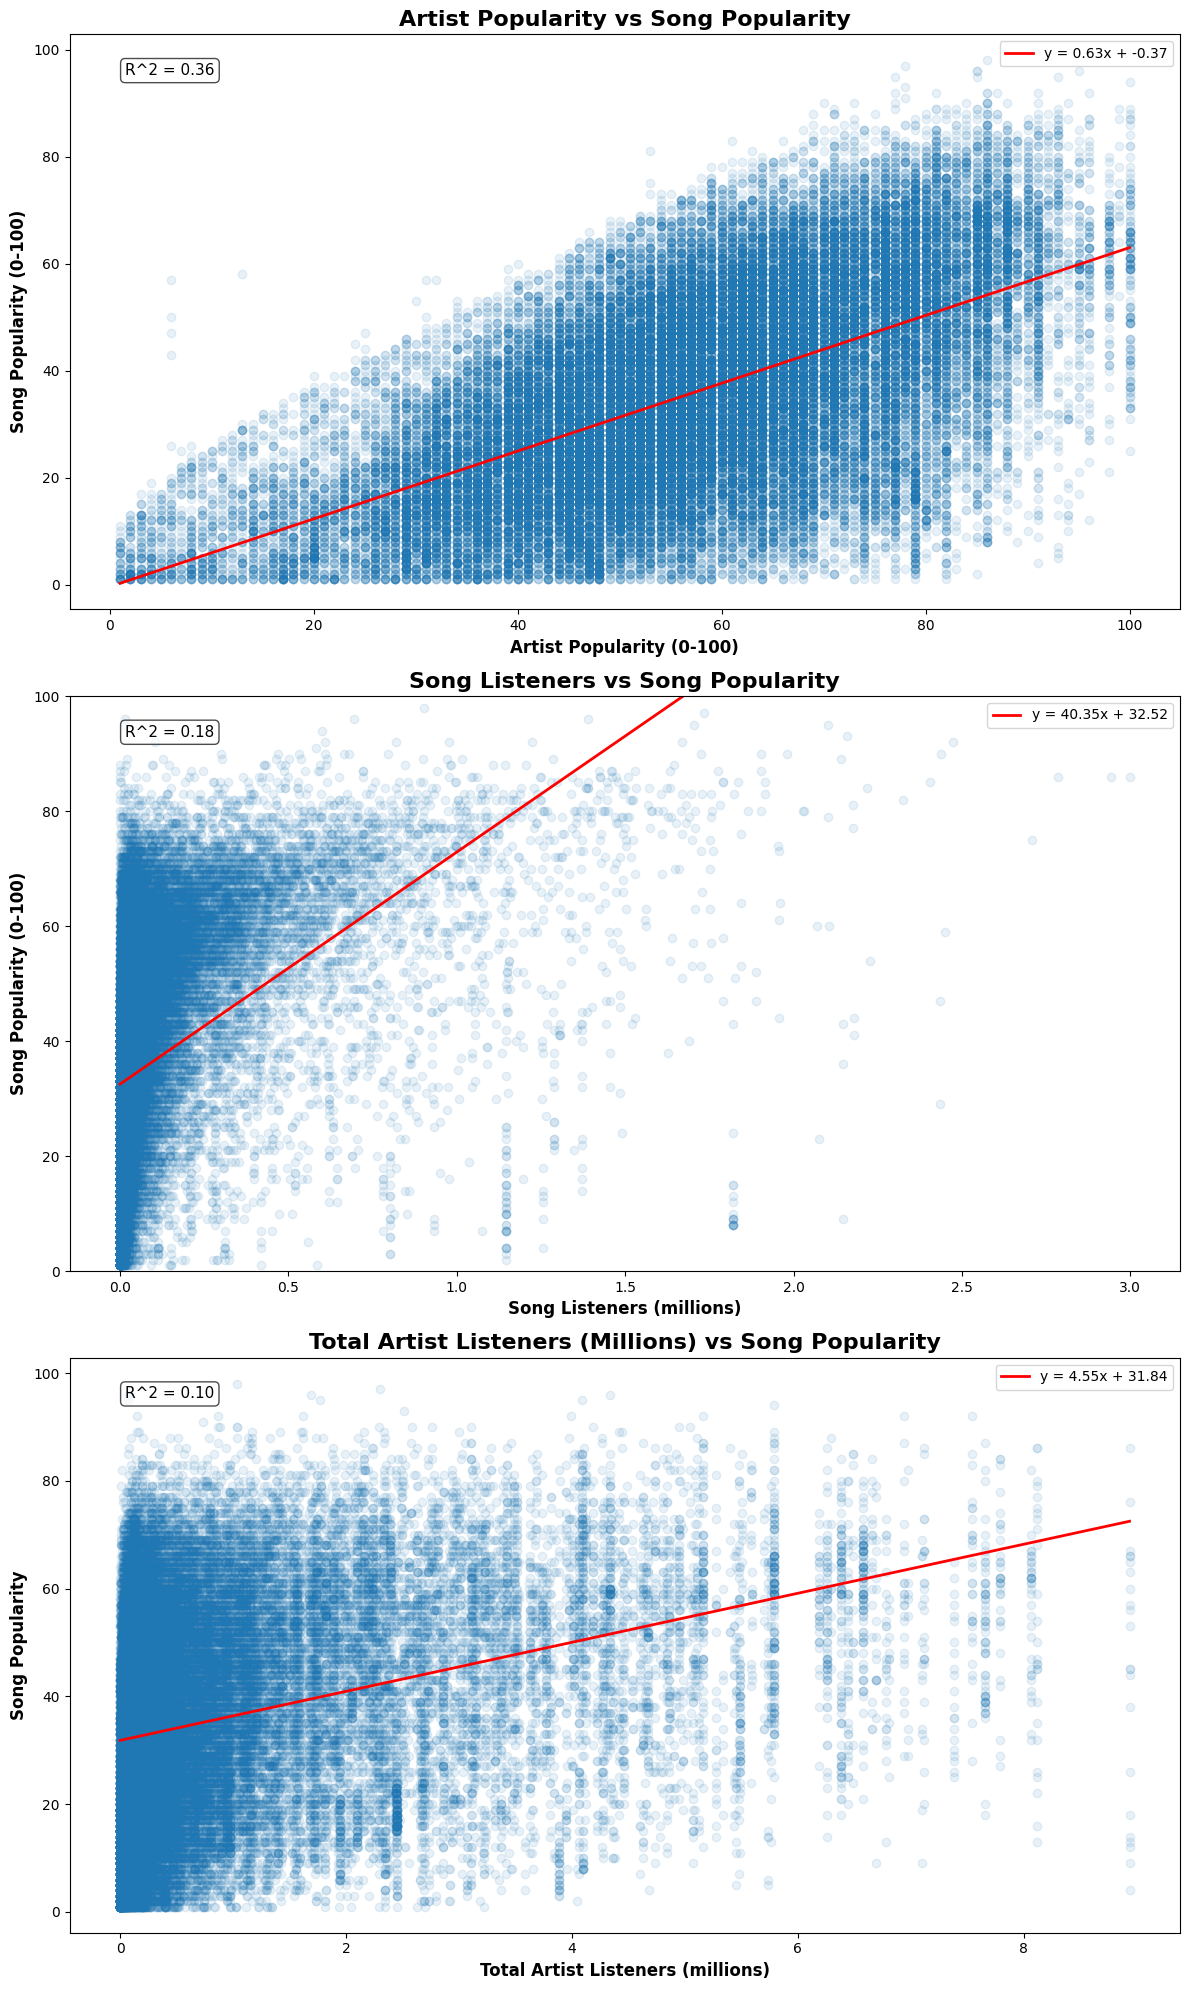

In [92]:
song_listeners_M = df['song_listeners'] / 1_000_000
total_listeners_M = df['total_listeners'] / 1_000_000

fig, axes = plt.subplots(3, 1, figsize=(12, 20))
pop = df['popularity']

axes[0].scatter(df['artist_popularity'], pop, alpha=.1)
axes[0].set_xlabel('Artist Popularity (0-100)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Song Popularity (0-100)', fontsize=12, fontweight='bold')
axes[0].set_title('Artist Popularity vs Song Popularity', fontsize=16, fontweight='bold')
m0, b0, x_range_0 = get_regression_info(df['artist_popularity'], pop)
axes[0].plot(x_range_0, m0*x_range_0+b0, color='red', linewidth=2, label=f'y = {m0:.2f}x + {b0:.2f}')
r0, _ = pearsonr(df['artist_popularity'], pop)
axes[0].text(.05, .95, f'R^2 = {r0**2:.2f}', transform=axes[0].transAxes,fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
axes[0].legend()

axes[1].scatter(song_listeners_M, pop, alpha=.1)
axes[1].set_xlabel('Song Listeners (millions)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Song Popularity (0-100)', fontsize=12, fontweight='bold')
axes[1].set_ylim(0,100)
axes[1].set_title('Song Listeners vs Song Popularity', fontsize=16, fontweight='bold')
m1, b1, x_range_1 = get_regression_info(song_listeners_M, pop)
axes[1].plot(x_range_1, m1*x_range_1+b1, linewidth=2, color='red', label=f'y = {m1:.2f}x + {b1:.2f}')
r1, _ = pearsonr(df['song_listeners'], pop)
axes[1].text(.05, .95, f'R^2 = {r1**2:.2f}', transform=axes[1].transAxes,fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
axes[1].legend()

axes[2].scatter(total_listeners_M, pop, alpha=.1)
axes[2].set_xlabel('Total Artist Listeners (millions)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Song Popularity', fontsize=12, fontweight='bold')
axes[2].set_title('Total Artist Listeners (Millions) vs Song Popularity', fontsize=16, fontweight='bold')
m2, b2, x_range_2 = get_regression_info(total_listeners_M, pop)
axes[2].plot(x_range_2, m2*x_range_2+b2, linewidth=2, color='red', label=f'y = {m2:.2f}x + {b2:.2f}')
r2, _= pearsonr(df['total_listeners'], pop)
axes[2].text(.05, .95, f'R^2 = {r2**2:.2f}', transform=axes[2].transAxes,fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
axes[2].legend()

plt.tight_layout()
plt.show()

Artist Popularity vs Song Popularity (R^2 = 0.36)

Of the three variables, artist popularity has the strongest linear relationship with song popularity, explaining 36% of the variance. There is a clear positive trend where songs from more popular artists tend to score higher on the popularity scale. However, the spread is very wide at every level of artist popularity, which tells us that even highly popular artists regularly release low-popularity tracks. The variance also appears to increase as artist popularity rises, meaning big artists have the widest range of song outcomes.

Song Listeners vs Song Popularity (R^2 = 0.18)

Song listener count has a moderate relationship with popularity, but the data is severely right-skewed — almost all songs sit below 0.5M listeners, with a long sparse tail stretching to 3M. This skew is distorting the regression line, which extends above 100 on the y-axis (an impossible value for popularity), a clear sign the linear fit is being pulled by extreme outliers. The true relationship here is likely stronger than R^2 = 0.18 suggests, and applying a log transformation to listener count would produce a much more reliable line.

Total Artist Listeners vs Song Popularity (R^2 = 0.10)

This is the weakest relationship of the three, which is somewhat counterintuitive because you might expect artists with massive audiences to produce more popular individual songs. The low R^2 suggests that total artist reach doesn't reliably translate to individual song success, possibly because mega-artists with 8M+ listeners still release albums with many low-stream tracks. Like song listeners, this variable is heavily skewed and a few extreme outliers are doing a lot of work on the regression line.

Overall, artist popularity is your strongest predictor here, while raw listener counts, both at the song and artist level, are noisy, skewed variables that would benefit from a log transform before using them in any further analysis or modeling.